In [2]:
!pip install opencv-python
!pip install matplotlib
!pip install numpy

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
print(cv2.__version__)

4.13.0


In [5]:
img=cv2.imread("apple.jpg")
print(type(img))
print(img.shape)
print(img.dtype)

<class 'numpy.ndarray'>
(168, 300, 3)
uint8


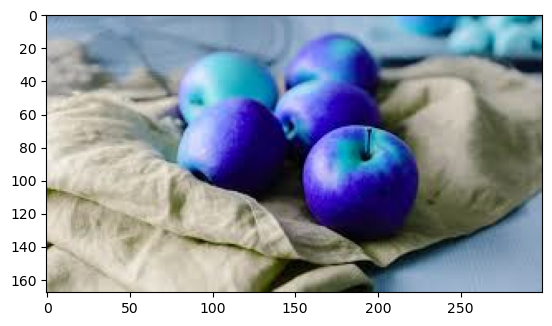

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [7]:
print("BGR")
print(img[0, 0])        
print(img[100, 200])   
print("________________")
print("RGB")
print(img_rgb[0, 0])       
print(img_rgb[100, 200])   


BGR
[104 128 156]
[ 35  20 158]
________________
RGB
[156 128 104]
[158  20  35]


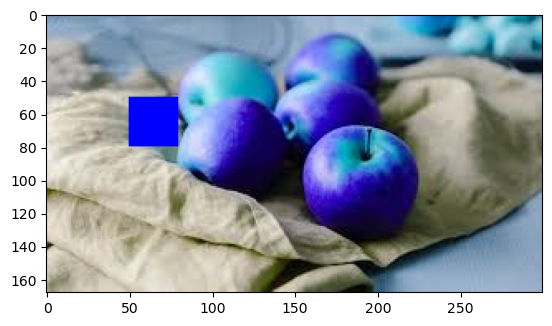

In [8]:
img[50:80, 50:80] = [0, 0, 255]   # red square
plt.imshow(img)

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray.shape)


(168, 300)


(np.float64(-0.5), np.float64(299.5), np.float64(167.5), np.float64(-0.5))

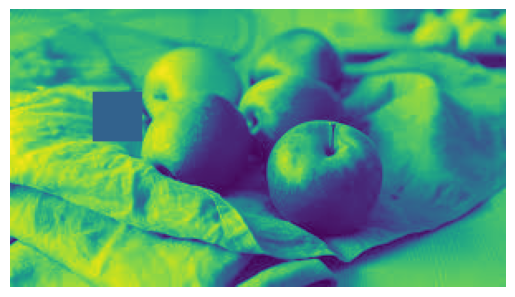

In [10]:
plt.imshow(gray )
# plt.imshow(gray, cmap="gray" )
plt.axis("off")


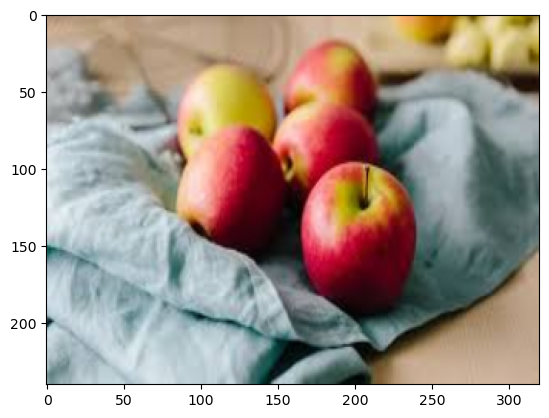

In [10]:
resized = cv2.resize(img_rgb, (320, 240))
plt.imshow(resized )

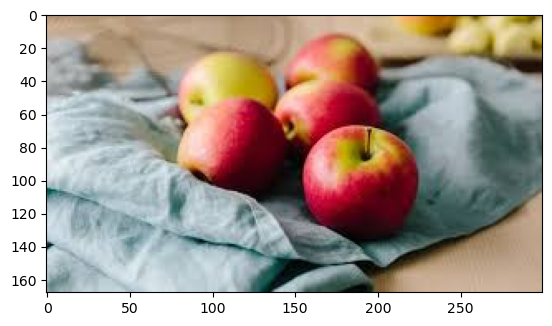

In [11]:
plt.imshow(img_rgb)

In [12]:
cv2.imwrite("output.jpg", resized)

True

In [13]:
def show(img, title="", gray=False):
    plt.figure(figsize=(5,5))
    if gray:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

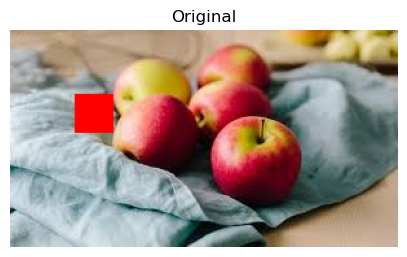

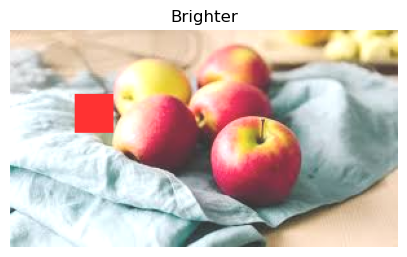

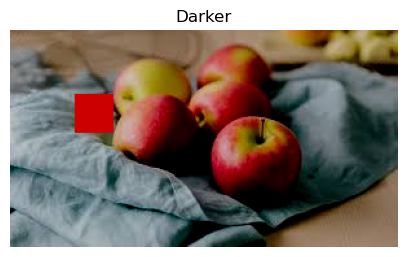

In [14]:
bright = cv2.add(img, 50)      # increase brightness
dark   = cv2.subtract(img, 50)

show(img, "Original")
show(bright, "Brighter")
show(dark, "Darker")

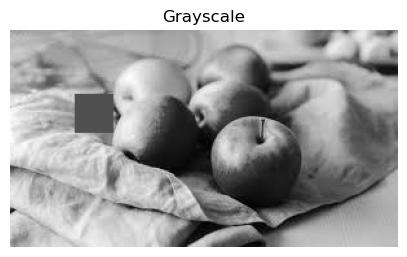

In [15]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show(gray, "Grayscale", gray=True)


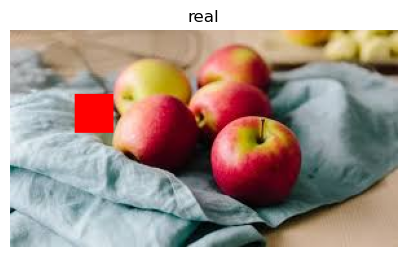

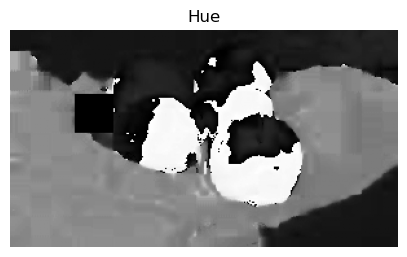

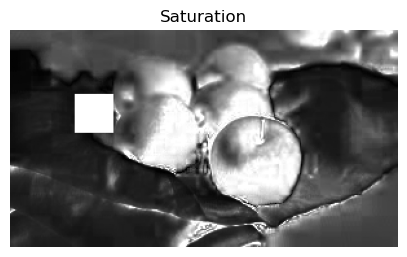

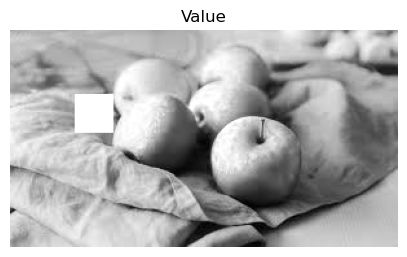

In [16]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)
show(img, "real")
show(h, "Hue", gray=True)
#  0 is red, 120 is green, and 240 is blue
show(s, "Saturation", gray=True)
show(v, "Value", gray=True)

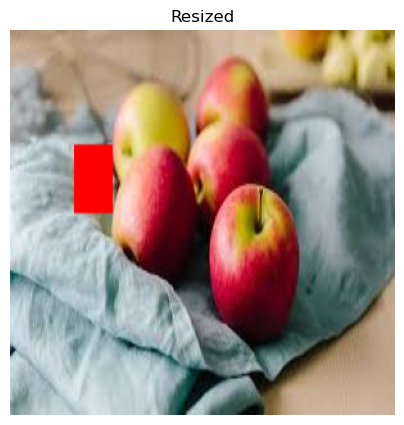

In [17]:
resized = cv2.resize(img, (300, 300))
show(resized, "Resized")


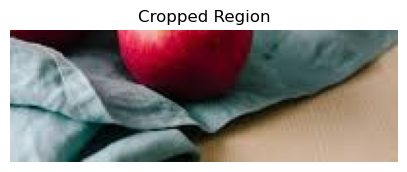

In [18]:
crop = img[100:1000, 100:300]
show(crop, "Cropped Region")

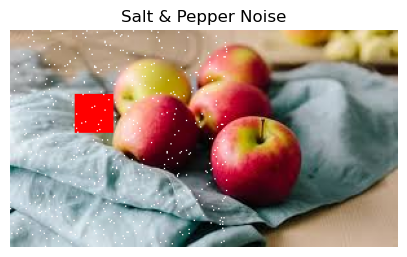

In [19]:
noise = img.copy()
coords = np.random.randint(0, noise.shape[0], (500, 2))
noise[coords[:,0], coords[:,1]] = 255
show(noise, "Salt & Pepper Noise")

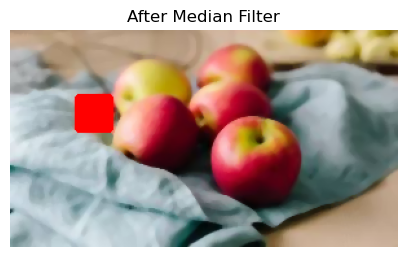

In [20]:
clean = cv2.medianBlur(noise, 5)
show(clean, "After Median Filter")

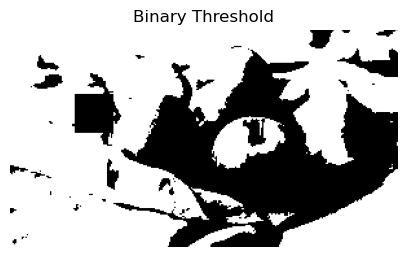

In [21]:
img2 = img
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

_, thresh = cv2.threshold(gray2, 127, 255, cv2.THRESH_BINARY)
show(thresh, "Binary Threshold", gray=True)


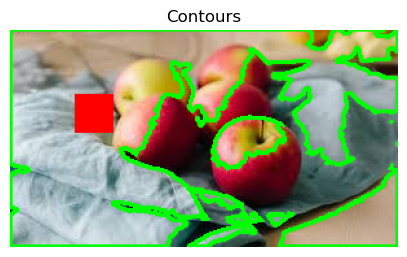

In [23]:
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

contour_img = img2.copy()
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)
show(contour_img, "Contours")

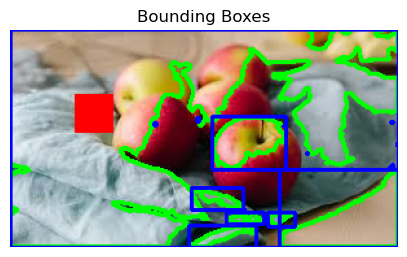

In [24]:
for cnt in contours:
    area = cv2.contourArea(cnt)
    x,y,w,h = cv2.boundingRect(cnt)
    cv2.rectangle(contour_img, (x,y), (x+w,y+h), (255,0,0), 2)

show(contour_img, "Bounding Boxes")


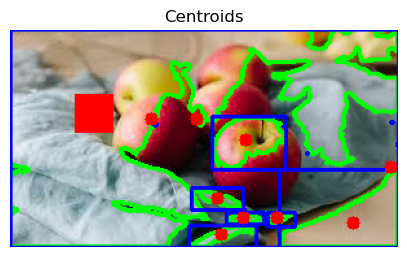

In [25]:
for cnt in contours:
    M = cv2.moments(cnt)
    if M["m00"] != 0:
        cx = int(M["m10"]/M["m00"])
        cy = int(M["m01"]/M["m00"])
        cv2.circle(contour_img, (cx,cy), 5, (0,0,255), -1)

show(contour_img, "Centroids")

In [26]:
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1500:
        print("Valid object detected")

Valid object detected
Valid object detected


In [11]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.putText(
        frame,
        "OpenCV Live Overlay",
        (30, 40),                     # position (x, y)
        cv2.FONT_HERSHEY_SIMPLEX,     # font
        1,                            # font scale
        (0,0, 255),                  # color (BGR)
        2                             # thickness
    )
    cv2.rectangle(frame, (50, 50), (200, 200), (255, 0, 0), 2)


    cv2.imshow("Live Overlay", frame)

    if cv2.waitKey(1) & 0xFF == 27:   # ESC to exit
        break

cap.release()
cv2.destroyAllWindows()
